Class implementation for CAX simulation module

```26/05/2026```

In [1]:
import Shadow
import numpy as np
import matplotlib.pyplot as plt

What do I need to accomplish? I need to be able to simulate the passage of light through the CAX beamline, from source through slits to DVF screen. I then need to be able to extract the resulting image at a given $y$ position (optical axis). Then I need to perform movements to the mirror and regenerate the image.

To create a general `CAXSim` class, I'll first write a basic `OpticalElement` wrapper class for Shadow OEs, then I'll create children with more specific methods, all the way to a `BeamLine` class that possesses the necessary attributes and methods to perform simulations and modify the system. 

In [2]:
def rotation_matrix(axis, angle):
    """
    Generate a rotation matrix for a given axis and angle.
    
    Parameters:
        axis (str): The axis of rotation ('x', 'y', or 'z').
        angle (float): The angle of rotation in degrees.
    
    Returns:
        np.ndarray: The 3x3 rotation matrix.
    """
    angle = np.radians(angle)
    c = np.cos(angle)
    s = np.sin(angle)

    if axis == 'x':
        return np.array([[1, 0, 0],
                         [0, c, -s],
                         [0, s, c]])
    elif axis == 'y':
        return np.array([[c, 0, s],
                         [0, 1, 0],
                         [-s, 0, c]])
    elif axis == 'z':
        return np.array([[c, -s, 0],
                         [s, c, 0],
                         [0, 0, 1]])
    else:
        raise ValueError("Axis must be 'x', 'y', or 'z'.")

In [3]:
class ReferenceFrame:
    """
    Right-handed orthonormal reference frame.

    Convention:
        v_lab = R @ v_local

    Columns of R are the local basis vectors expressed
    in lab coordinates.
    """

    def __init__(self, origin=None, orientation=None, name=None):

        self.name = name or "frame"

        self.origin = np.array(
            origin if origin is not None else [0., 0., 0.],
            dtype=float
        )

        self.R = np.array(
            orientation if orientation is not None else np.eye(3),
            dtype=float
        )

        self._validate_rotation_matrix()

    # -------------------------------------------------
    # Validation
    # -------------------------------------------------

    def _validate_rotation_matrix(self, atol=1e-10):

        should_be_identity = self.R.T @ self.R

        if not np.allclose(should_be_identity, np.eye(3), atol=atol):
            raise ValueError("Orientation matrix is not orthogonal")

        det = np.linalg.det(self.R)

        if not np.isclose(det, 1.0, atol=atol):
            raise ValueError("Orientation matrix must have determinant +1")

    # -------------------------------------------------
    # Vector transforms
    # -------------------------------------------------

    def vector_to_lab(self, v_local):
        v_local = np.asarray(v_local, dtype=float)
        return self.R @ v_local

    def vector_from_lab(self, v_lab):
        v_lab = np.asarray(v_lab, dtype=float)
        return self.R.T @ v_lab

    # -------------------------------------------------
    # Point transforms
    # -------------------------------------------------

    def point_to_lab(self, p_local):
        p_local = np.asarray(p_local, dtype=float)
        return self.origin + self.R @ p_local

    def point_from_lab(self, p_lab):
        p_lab = np.asarray(p_lab, dtype=float)
        return self.R.T @ (p_lab - self.origin)

    # -------------------------------------------------
    # Relative frame construction
    # -------------------------------------------------

    def child_frame(self, relative_origin, relative_rotation, name=None):
        """
        Create a new frame defined relative to THIS frame.
        """

        relative_origin = np.asarray(relative_origin, dtype=float)
        relative_rotation = np.asarray(relative_rotation, dtype=float)

        new_origin = self.point_to_lab(relative_origin)
        new_rotation = self.R @ relative_rotation

        return ReferenceFrame(
            origin=new_origin,
            orientation=new_rotation,
            name=name
        )

    # -------------------------------------------------
    # Relations between frames
    # -------------------------------------------------

    def rotation_to(self, other):
        """
        Rotation matrix mapping vectors from this frame
        into another frame.
        """

        return other.R.T @ self.R

    def __repr__(self):
        return (
            f"ReferenceFrame(name={self.name}, "
            f"origin={self.origin})"
        )

In [ ]:
class OpticalElement:
    """
    A wrapper class for a Shadow optical element, 
    providing methods to load specifications and interact with the element.
    """

    def __init__(self, name: str, specification_file: str):
        self.name = name
        self.shadow_oe = Shadow.OE()
        self.specification_file = specification_file
        self.load_specification()
        # To be set when the element is added to a beamline
        self.frame = None  
        self.beamline = None
        # Flag to track if the element has been updated since last load
        self.updated = False  
        # Original properties to reset after simulation
        self.specification = self.shadow_oe.to_dictionary()
        # Image
        self.image = None
        # Persistent attributes that should not be reset after simulation
        self.persistent_attributes = []
        
    # General attributes    
        
    @property
    def orientation(self):
        """
        Optical element orientation angle (degrees) relative to the previous element.
        Positive values indicate counter-clockwise rotation.
        """
        return self.shadow_oe.ALPHA
    

    @property
    def source_distance(self):
        """
        Distance from the previous element to the source point (user units).
        """
        return self.shadow_oe.T_SOURCE
    
    @property 
    def image_distance(self):
        """
        Distance from the previous element to the image point (user units).
        """
        return self.shadow_oe.T_IMAGE 

    @property
    def units(self):
        """
        User units for distances.
        """

        return self.shadow_oe.unit()
    

    def load_specification(self, specification_file: str = None):
        """
        Load the optical element specification from a file.
        
        Parameters:
            specification_file (str): The path to the specification file. 
            If None, uses the default specification file.
        """

        if specification_file is None:
            specification_file = self.specification_file
        self.shadow_oe.load(specification_file)
        # self.specification = self.shadow_oe.to_dictionary()


class Source():
    """
    A wrapper class for a Shadow source optical element.
    """

    def __init__(self, name: str, specification_file: str):
        self.name = name
        self.shadow_oe = Shadow.Source()
        self.specification_file = specification_file
        self.load_specification()
        self.frame = None  # To be set when the element is added to a beamline
    
    def load_specification(self, specification_file: str = None):
        """
        Load the optical element specification from a file.
        
        Parameters:
            specification_file (str): The path to the specification file. 
            If None, uses the default specification file.
        """

        if specification_file is None:
            specification_file = self.specification_file
        self.shadow_oe.load(specification_file)

class BendingMagnet(Source):
    """
    A wrapper class for a Shadow bending magnet optical element.
    """

    def __init__(self, name: str, specification_file: str):
        super().__init__(name, specification_file)
        
        if self.shadow_oe.FDISTR != 4:
            raise ValueError(f"File {specification_file} is not"
                             f" configured for a synchrotron source.")

class ToroidalMirror(OpticalElement):
    """
    A wrapper class for a Shadow toroidal mirror optical element.
    """

    def __init__(self, name: str, specification_file: str):
        super().__init__(name, specification_file)
        
        if self.shadow_oe.FMIRR != 3:
            raise ValueError(f"File {specification_file} is not"
                             f" configured for a toroidal mirror: "
                             f"FMIRR = {self.shadow_oe.FMIRR}")


    @property
    def offset(self):
        """
        Get the current offset of the mirror's position in the global frame.
        
        Returns:
            np.ndarray: A 3D vector representing the offset in the global frame.
        """
        if self.frame is None:
            raise ValueError("Mirror frame is not defined. Please add the mirror to a beamline first.")
        
        offset_local = np.array([
            self.shadow_oe.OFFX,
            self.shadow_oe.OFFY,
            self.shadow_oe.OFFZ
        ])
        
        return self.frame.vector_to_lab(offset_local)
    
    @offset.setter
    def offset(self, offset_vector: np.ndarray):
        """
        Apply an offset to the mirror's position.
        
        Parameters:
            offset_vector (np.ndarray): A 3D vector representing the offset in the mirror's local frame.
        """
        if self.frame is None:
            raise ValueError("Mirror frame is not defined. Please add the mirror to a beamline first.")
        
        # Convert the offset vector from the mirror's local frame to the lab frame
        offset_local = self.frame.vector_from_lab(offset_vector)
        
        self.shadow_oe.OFFX = offset_local[0]
        self.shadow_oe.OFFY = offset_local[1]
        self.shadow_oe.OFFZ = offset_local[2]

    @property
    def tilt(self):
        """
        Get the current tilt angles of the mirror's orientation in the global frame.
        
        Returns:
            np.ndarray: A 3D vector representing the tilt angles (in degrees) around the lab frame axes.
        """
        if self.frame is None:
            raise ValueError("Mirror frame is not defined. Please add the mirror to a beamline first.")
        
        tilt_local = np.array([
            self.shadow_oe.X_ROT,
            self.shadow_oe.Y_ROT,
            self.shadow_oe.Z_ROT
        ])
        
        return self.frame.vector_to_lab(tilt_local)

    @tilt.setter
    def tilt(self, tilt_angles: np.ndarray):
        """
        Apply tilts to the mirror's orientation.
        
        Parameters:
            tilt_angles (np.ndarray): A 3D vector representing the tilt angles 
            (in degrees) around the lab frame axes.
        """
        if self.frame is None:
            raise ValueError("Mirror frame is not defined. Please add the mirror to a beamline first.")
        
        # Convert the tilt angles from the mirror's local frame to the lab frame
        self.tilt_global = tilt_angles
        self.tilt_local = self.frame.vector_from_lab(tilt_angles)
        
        self.shadow_oe.X_ROT = self.tilt_local[0]
        self.shadow_oe.Y_ROT = self.tilt_local[1]
        self.shadow_oe.Z_ROT = self.tilt_local[2]

class Screen(OpticalElement):
    """
    A wrapper class for a Shadow screen optical element.
    """

    def __init__(self, name: str, specification_file: str, screen_dimensions: tuple = (5., 5.)):
        super().__init__(name, specification_file)
        
        if self.shadow_oe.F_SCREEN != 1:
            raise ValueError(f"File {specification_file} is not"
                             f" configured for a screen: "
                             f"F_SCREEN = {self.shadow_oe.F_SCREEN}")

class Slits(Screen):
    """
    A wrapper class for a Shadow slits optical element.
    """

    def __init__(self, name: str, specification_file: str, slit_positions: tuple = (0., 0.)):
        super().__init__(name, specification_file)
        
        if any(self.shadow_oe.I_SLIT) != 1:
            raise ValueError(f"File {specification_file} is not"
                             f" configured for slits: "
                             f"I_SLIT = {self.shadow_oe.I_SLIT}")


In [63]:
class BeamLine:
    """
    A class representing a beamline, which is a sequence of optical elements.
    """

    def __init__(self, name: str, beam: Shadow.Beam, source: Source, optical_elements: list = None, 
                 beamline_frame=None, lab_frame=None):
        self.name = name
        self.beam = beam
        self.source = source
        self.elements = optical_elements if optical_elements is not None else []
        self.beamline_frame = beamline_frame
        self.lab_frame = lab_frame
        self.construct_frames()

        self.beam.genSource(self.source.shadow_oe)

        self.beams = [self.beam.duplicate()]  # List to hold beams at each stage of the beamline

    def construct_frames(self):
        """
        Construct the reference frames for each optical element in the beamline.
        The source reference frame is defined relative to the beamline frame, 
        and each subsequent elements are defined relative to the previous element's frame.
        """
        if self.beamline_frame is None:
            raise ValueError("Beamline frame is not defined.")
        
        self.source.frame = self.beamline_frame.child_frame(relative_origin=[0, 0, 0], 
                                                            relative_rotation=np.eye(3),
                                                            name=f"{self.name}_{self.source.name}_frame")
        current_frame = self.source.frame

        # Iterate through the optical elements and construct their frames
        # Orientation is relative to the previous element, using the left-hand 
        # rule for positive angles
        for element in self.elements:
            relative_origin = [0, element.source_distance, 0]
            relative_orientation = rotation_matrix('y', -element.orientation)
            element.frame = current_frame.child_frame(relative_origin, 
                                                      relative_orientation,
                                                      name=f"{element.name}_frame")
            current_frame = element.frame

    def trace(self):
        """
        Trace the beam through the whole beamline.
        """
        
        for i, element in enumerate(self.elements):
            self.beam.traceOE(element.shadow_oe, i+1)
            
            # Store the beam after each element
            self.beams.append(self.beam.duplicate())

            lab_xhat = np.array([1, 0, 0])  #Lab x direction
            lab_yhat = np.array([0, 1, 0])  #Lab y direction

            local_x = element.frame.vector_from_lab(lab_xhat)
            local_y = element.frame.vector_from_lab(lab_yhat)

            x_index = np.argmax(np.abs(local_x))+1 # 1 = x, 2 = y, 3 = z
            y_index = np.argmax(np.abs(local_y))+1 # 1 = x, 2 = y, 3 = z

            element.image = self.beam.histo2(col_h=x_index, col_v=y_index, 
                                             nbins=200, nolost=1)
        



In [87]:
source = BendingMagnet("B1", "source.props")

In [7]:
len(source.shadow_oe.to_dictionary())

101

In [8]:
beam = Shadow.Beam()
beam.genSource(source.shadow_oe)

 Generated        50000  rays out of      1000000
                 100000
                 150000
                 200000
                 250000
                 300000
                 350000
                 400000
                 450000
                 500000
                 550000
                 600000
                 650000
                 700000
                 750000
                 800000
                 850000
                 900000
                 950000
                1000000
 Exit from SOURCE


In [9]:
len(source.shadow_oe.to_dictionary())

101

In [88]:
mirror = ToroidalMirror("M1", "mirror.props")
mirror.orientation
mirror.source_distance

17000.0

In [16]:
mirror.offset

ValueError: Mirror frame is not defined. Please add the mirror to a beamline first.

In [89]:
slit = Slits("Slit_A1", "slits.props")

In [90]:
screen = Screen("DVF_B1", "screen.props")

In [ ]:
mirror.offset = []

In [91]:
sirius_frame = ReferenceFrame(name="sirius")

In [92]:
R1 = rotation_matrix('x', 90)
R2 = rotation_matrix('y', 180)
source_R = R1 @ R2
shadow_frame = sirius_frame.child_frame(relative_origin=[0, 0, 0], 
                                        relative_rotation=source_R, 
                                        name="shadow")

In [93]:
optical_elements = [mirror, slit, screen]

In [94]:
beam = Shadow.Beam()

In [95]:
cax = BeamLine(name="CAX", source=source, optical_elements=optical_elements,
               beamline_frame=shadow_frame, lab_frame=sirius_frame, beam=beam)

 Generated        50000  rays out of      1000000
                 100000
                 150000
                 200000
                 250000
                 300000
                 350000
                 400000
                 450000
                 500000
                 550000
                 600000
                 650000
                 700000
                 750000
                 800000
                 850000
                 900000
                 950000
                1000000
 Exit from SOURCE


In [96]:
cax.trace()

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to I

In [97]:
screen.image

{'error': 1,
 'col_h': 3,
 'col_v': 1,
 'nolost': 1,
 'nbins_h': 200,
 'nbins_v': 200,
 'ref': 23,
 'xrange': [-0.11583923643210375, 0.10546556645071395],
 'yrange': [-0.06320281123038075, 0.06867562980833974],
 'bin_h_edges': array([-0.11583924, -0.11473271, -0.11362619, -0.11251966, -0.11141314,
        -0.11030662, -0.10920009, -0.10809357, -0.10698704, -0.10588052,
        -0.104774  , -0.10366747, -0.10256095, -0.10145442, -0.1003479 ,
        -0.09924138, -0.09813485, -0.09702833, -0.0959218 , -0.09481528,
        -0.09370876, -0.09260223, -0.09149571, -0.09038918, -0.08928266,
        -0.08817614, -0.08706961, -0.08596309, -0.08485656, -0.08375004,
        -0.08264352, -0.08153699, -0.08043047, -0.07932394, -0.07821742,
        -0.0771109 , -0.07600437, -0.07489785, -0.07379132, -0.0726848 ,
        -0.07157828, -0.07047175, -0.06936523, -0.0682587 , -0.06715218,
        -0.06604566, -0.06493913, -0.06383261, -0.06272608, -0.06161956,
        -0.06051304, -0.05940651, -0.0582999

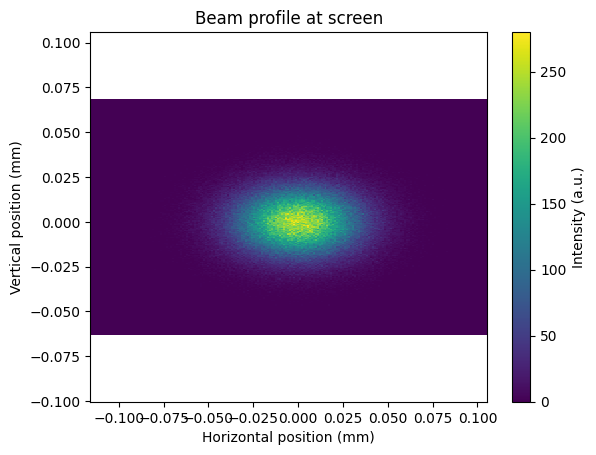

In [98]:
import matplotlib.pyplot as plt

ticket = screen.image

plt.pcolormesh(ticket["bin_h_edges"], ticket["bin_v_edges"], ticket["histogram"].T)
plt.xlabel("Horizontal position (mm)")
plt.ylabel("Vertical position (mm)")
plt.title("Beam profile at screen")
plt.colorbar(label="Intensity (a.u.)")
plt.axis('equal')
plt.show()

In [99]:
mirror.specification

{'ALFA': 0.0,
 'ALPHA': 90.0,
 'ALPHA_I': 0.0,
 'ALPHA_S': 0.0,
 'AXMAJ': 0.0,
 'AXMIN': 0.0,
 'AZIM_FAN': 0.0,
 'A_BRAGG': 0.0,
 'BLAZE': 0.0,
 'CCC': array([ 1.,  1.,  1.,  0.,  0.,  0.,  0.,  0., -0.,  0.]),
 'CIL_ANG': 0.0,
 'COD_LEN': 0.0,
 'COD_WID': 0.0,
 'COMA_FAC': 0.0,
 'CONE_A': 0.0,
 'CX_SLIT': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'CZ_SLIT': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'DIST_FAN': 0.0,
 'DUMMY': 0.1,
 'D_PLATE': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'D_SPACING': 0.0,
 'ELL_THE': 0.0,
 'FCYL': 0,
 'FHIT_C': 1,
 'FILE_ABS': array([b'                                                                                                                                                                                                                                                                                                                                                                                                                    

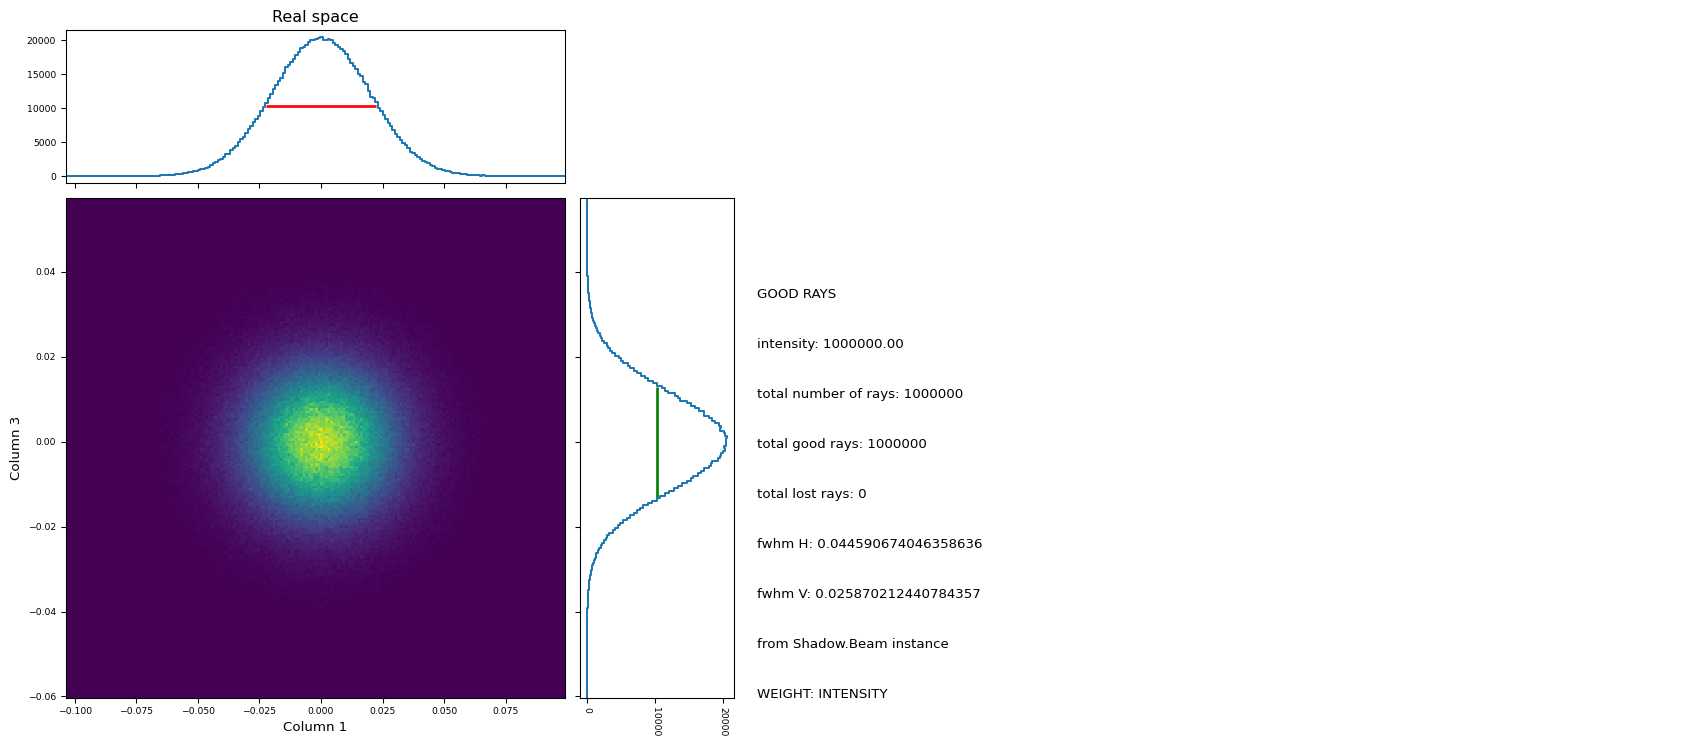

{'error': 1,
 'col_h': 1,
 'col_v': 3,
 'nolost': 1,
 'nbins_h': 200,
 'nbins_v': 200,
 'ref': 23,
 'xrange': [-0.10371376075817759, 0.0989711212707245],
 'yrange': [-0.06030214211874645, 0.05728973261209128],
 'bin_h_edges': array([-0.10371376, -0.10270034, -0.10168691, -0.10067349, -0.09966006,
        -0.09864664, -0.09763321, -0.09661979, -0.09560637, -0.09459294,
        -0.09357952, -0.09256609, -0.09155267, -0.09053924, -0.08952582,
        -0.08851239, -0.08749897, -0.08648555, -0.08547212, -0.0844587 ,
        -0.08344527, -0.08243185, -0.08141842, -0.080405  , -0.07939157,
        -0.07837815, -0.07736473, -0.0763513 , -0.07533788, -0.07432445,
        -0.07331103, -0.0722976 , -0.07128418, -0.07027076, -0.06925733,
        -0.06824391, -0.06723048, -0.06621706, -0.06520363, -0.06419021,
        -0.06317678, -0.06216336, -0.06114994, -0.06013651, -0.05912309,
        -0.05810966, -0.05709624, -0.05608281, -0.05506939, -0.05405596,
        -0.05304254, -0.05202912, -0.05101569

In [62]:
Shadow.ShadowTools.plotxy(cax.beams[0],1,3,nbins=200,nolost=1,title="Real space")


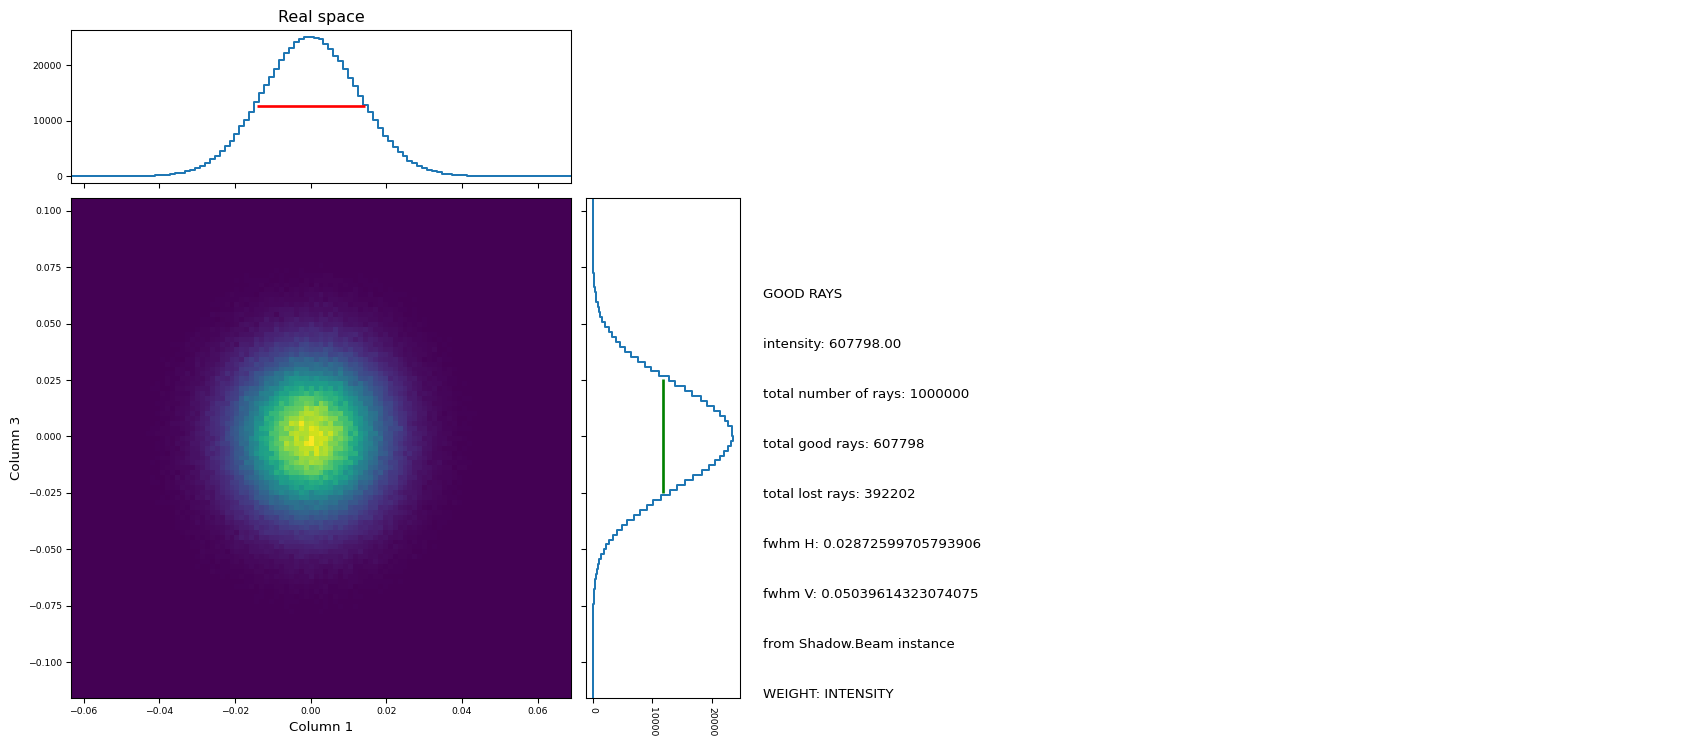

{'error': 1,
 'col_h': 1,
 'col_v': 3,
 'nolost': 1,
 'nbins_h': 101,
 'nbins_v': 101,
 'ref': 23,
 'xrange': [-0.06320281123038075, 0.06867562980833974],
 'yrange': [-0.11583923643210375, 0.10546556645071395],
 'bin_h_edges': array([-0.06320281, -0.06189708, -0.06059136, -0.05928563, -0.0579799 ,
        -0.05667418, -0.05536845, -0.05406272, -0.05275699, -0.05145127,
        -0.05014554, -0.04883981, -0.04753409, -0.04622836, -0.04492263,
        -0.0436169 , -0.04231118, -0.04100545, -0.03969972, -0.038394  ,
        -0.03708827, -0.03578254, -0.03447681, -0.03317109, -0.03186536,
        -0.03055963, -0.02925391, -0.02794818, -0.02664245, -0.02533672,
        -0.024031  , -0.02272527, -0.02141954, -0.02011382, -0.01880809,
        -0.01750236, -0.01619663, -0.01489091, -0.01358518, -0.01227945,
        -0.01097373, -0.009668  , -0.00836227, -0.00705654, -0.00575082,
        -0.00444509, -0.00313936, -0.00183364, -0.00052791,  0.00077782,
         0.00208355,  0.00338927,  0.004695 

In [58]:
Shadow.ShadowTools.plotxy(cax.beams[3],1,3,nbins=101,nolost=1,title="Real space")


In [38]:
cax.beam.retrace(12641)

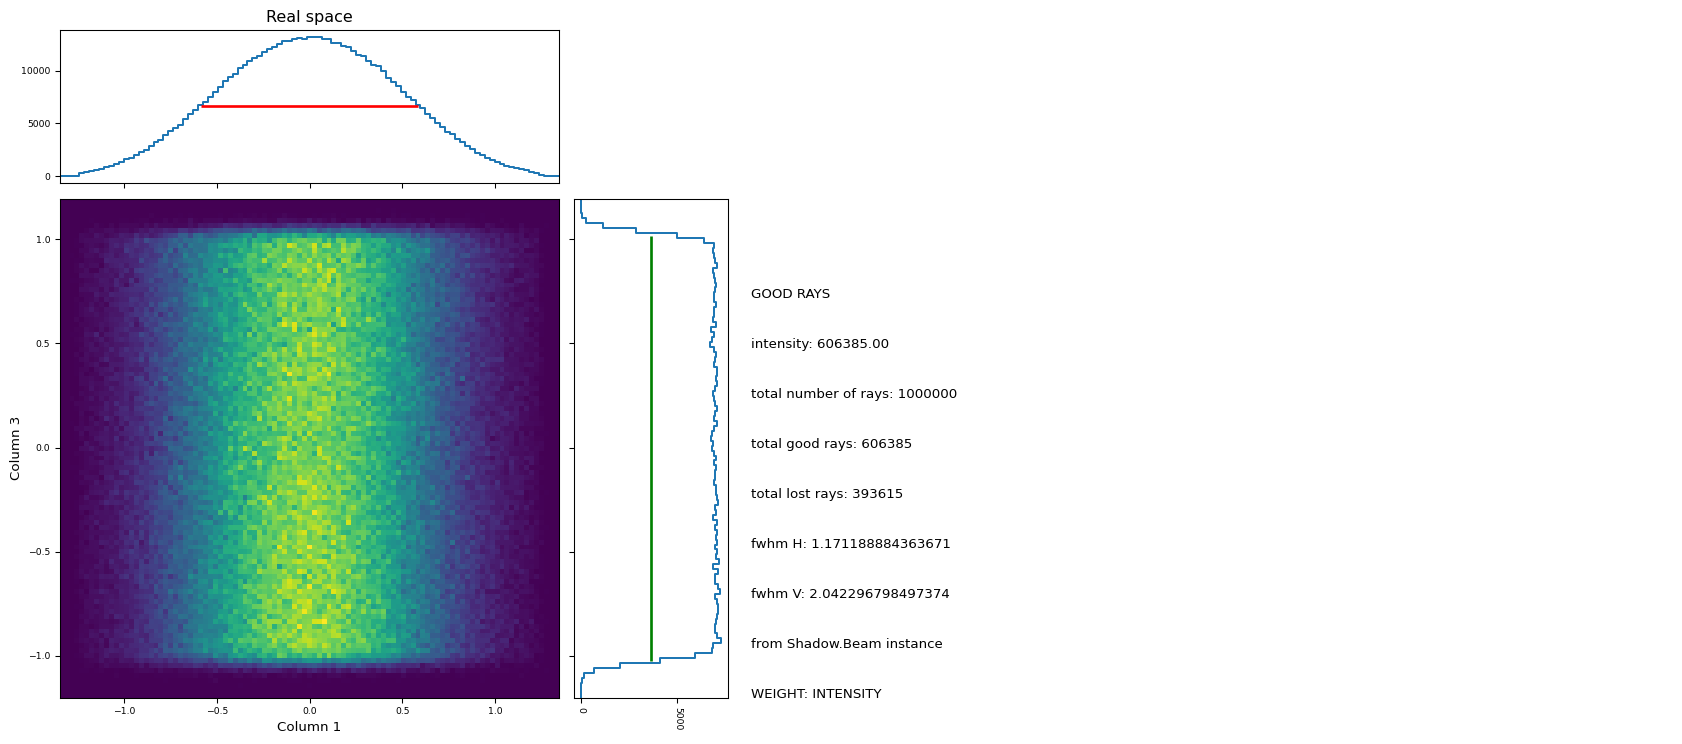

{'error': 1,
 'col_h': 1,
 'col_v': 3,
 'nolost': 1,
 'nbins_h': 101,
 'nbins_v': 101,
 'ref': 23,
 'xrange': [-1.3462920410519745, 1.3421188071464458],
 'yrange': [-1.202005473209148, 1.1965058831656823],
 'bin_h_edges': array([-1.34629204, -1.31967411, -1.29305618, -1.26643825, -1.23982032,
        -1.2132024 , -1.18658447, -1.15996654, -1.13334861, -1.10673068,
        -1.08011275, -1.05349482, -1.02687689, -1.00025896, -0.97364103,
        -0.9470231 , -0.92040517, -0.89378724, -0.86716932, -0.84055139,
        -0.81393346, -0.78731553, -0.7606976 , -0.73407967, -0.70746174,
        -0.68084381, -0.65422588, -0.62760795, -0.60099002, -0.57437209,
        -0.54775417, -0.52113624, -0.49451831, -0.46790038, -0.44128245,
        -0.41466452, -0.38804659, -0.36142866, -0.33481073, -0.3081928 ,
        -0.28157487, -0.25495694, -0.22833902, -0.20172109, -0.17510316,
        -0.14848523, -0.1218673 , -0.09524937, -0.06863144, -0.04201351,
        -0.01539558,  0.01122235,  0.03784028,  0

In [41]:
Shadow.ShadowTools.plotxy(cax.beam,1,3,nbins=101,nolost=1,title="Real space")


In [ ]:
cax.elements[1].frame

ReferenceFrame(name=Slit_A1_frame, origin=[0.00000000e+00 1.04094978e-12 1.70000000e+04])

In [ ]:
mirror.offset

array([0.1, 0.2, 0.3])

In [ ]:
mirror.offset = [0.1, 0.2, 0.3]

In [ ]:
source_x_vec = np.array([1, 0, 0])
source_y_vec = np.array([0, 1, 0])
source_z_vec = np.array([0, 0, 1])


In [ ]:
shadow_source_frame.vector_to_lab(source_z_vec)

array([ 1.2246468e-16,  1.0000000e+00, -6.1232340e-17])

In [ ]:
mirror_R = rot_matrix('y', -np.pi/2)

In [ ]:
shadow_mirror_frame = shadow_source_frame.child_frame(relative_origin=[0, 17000, 0],
                                                      relative_rotation=mirror_R,
                                                      name="shadow_mirror")

In [ ]:
mirror_x_vec = np.eye(3)[0]
mirror_y_vec = np.eye(3)[1]
mirror_z_vec = np.eye(3)[2]


In [ ]:
print(f"Mirror X vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_x_vec))}")
print(f"Mirror Y vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_y_vec))}")
print(f"Mirror Z vector in lab frame: {np.round(shadow_mirror_frame.vector_to_lab(mirror_z_vec))}")

Mirror X vector in lab frame: [ 0.  1. -0.]
Mirror Y vector in lab frame: [0. 0. 1.]
Mirror Z vector in lab frame: [ 1. -0.  0.]


In [ ]:
shadow_screens_frame = shadow_mirror_frame.child_frame(relative_origin=[0, 4359, 0],
                                                      relative_rotation=np.eye(3),
                                                      name="shadow_screen")

In [ ]:
np.round(shadow_screens_frame.point_to_lab(shadow_screens_frame.origin)[2]+12641)

34000.0